# Overlap Variation Analysis: Energy Barrier vs Overlap Length

This notebook investigates the hypothesis that **energy barriers increase with increasing gene overlap**.

## Approach:
1. For each overlap value, generate a small pool of functional sequences
2. Select the pair with lowest Hamming distance (easiest evolutionary path)
3. Use Genetic Algorithm to find optimal mutation ordering
4. Record the maximum energy barrier along the path
5. Plot energy barrier vs overlap to test the hypothesis

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
from tqdm.auto import tqdm
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')

# Import local module
import overlappingGenes as og

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Reproducibility
np.random.seed(42)

c:\Users\orson\anaconda3\envs\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load DCA Parameters

In [2]:
PROTEIN_1 = 'PF00004'
PROTEIN_2 = 'PF00041'

print(f"Loading DCA parameters for {PROTEIN_1}...")
Jvec_1, hvec_1 = og.extract_params(f'{PROTEIN_1}/{PROTEIN_1}_params.dat')
nat_energies_1 = og.load_natural_energies(f'{PROTEIN_1}/{PROTEIN_1}_naturalenergies.txt')
mean_e1, std_e1 = np.mean(nat_energies_1), np.std(nat_energies_1)
print(f"  Length: {len(hvec_1)//21} AA, Mean energy: {mean_e1:.2f} ± {std_e1:.2f}")

print(f"\nLoading DCA parameters for {PROTEIN_2}...")
Jvec_2, hvec_2 = og.extract_params(f'{PROTEIN_2}/{PROTEIN_2}_params.dat')
nat_energies_2 = og.load_natural_energies(f'{PROTEIN_2}/{PROTEIN_2}_naturalenergies.txt')
mean_e2, std_e2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"  Length: {len(hvec_2)//21} AA, Mean energy: {mean_e2:.2f} ± {std_e2:.2f}")

DCA_params_1 = (Jvec_1, hvec_1)
DCA_params_2 = (Jvec_2, hvec_2)

prot1_len = len(hvec_1) // 21
prot2_len = len(hvec_2) // 21
print(f"\nProtein 1 length: {prot1_len} AA")
print(f"Protein 2 length: {prot2_len} AA")

Loading DCA parameters for PF00004...
  Length: 110 AA, Mean energy: 145.88 ± 38.25

Loading DCA parameters for PF00041...
  Length: 74 AA, Mean energy: 120.66 ± 17.64

Protein 1 length: 110 AA
Protein 2 length: 74 AA


## 3. Configuration

In [3]:
# Overlap values to scan (nucleotides)
# Start at 12 (minimum reliable), go up to 60 in steps of 12
OVERLAPS = range(12, 61, 3)

# Sequence generation parameters
N_SEQUENCES = 15       # Sequences per overlap (small to avoid memory issues)
MC_ITERATIONS = 250_000  # MC iterations per sequence
MC_TEMP_1 = 0.818
MC_TEMP_2 = 0.955

# Genetic Algorithm parameters
GA_POPULATION = 100
GA_GENERATIONS = 150

# --- NORMALIZATION ---
Z_SCORE = True               # If True, normalize distances using z-scores

# Dynamic plot labels based on Z_SCORE
DIST_LABEL = "Z-Score Distance" if Z_SCORE else "Distance from Natural"
MAX_DIST_LABEL = "Max Z-Score Distance" if Z_SCORE else "Max Distance from Natural"

print(f"Overlaps to scan: {OVERLAPS}")
print(f"Sequences per overlap: {N_SEQUENCES}")
print(f"MC iterations: {MC_ITERATIONS:,}")
print(f"GA: {GA_POPULATION} pop x {GA_GENERATIONS} gen")
print(f"Z-Score normalization: {Z_SCORE}")

Overlaps to scan: range(12, 61, 3)
Sequences per overlap: 15
MC iterations: 250,000
GA: 100 pop x 150 gen
Z-Score normalization: True


## 4. Core Functions

In [4]:
# =============================================================================
# NUMBA-OPTIMIZED HELPER FUNCTIONS FOR GA
# =============================================================================

from numba import prange

# Nucleotide encoding: A=0, C=1, G=2, T=3
NT_TO_INT = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
INT_TO_NT = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

def seq_to_array(seq_str):
    """Convert string sequence to numpy uint8 array."""
    return np.array([NT_TO_INT[c] for c in seq_str], dtype=np.uint8)

def array_to_seq(seq_arr):
    """Convert numpy uint8 array back to string."""
    return ''.join(INT_TO_NT[i] for i in seq_arr)

def get_mutations_arrays(seq1, seq2):
    """Get mutations as numpy arrays for numba compatibility."""
    positions = []
    old_nts = []
    new_nts = []
    for i in range(len(seq1)):
        if seq1[i] != seq2[i]:
            positions.append(i)
            old_nts.append(NT_TO_INT[seq1[i]])
            new_nts.append(NT_TO_INT[seq2[i]])
    return (np.array(positions, dtype=np.int32),
            np.array(old_nts, dtype=np.uint8),
            np.array(new_nts, dtype=np.uint8))


@njit
def calculate_energies_from_array(seq_arr, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2):
    """
    Calculate E1 and E2 from a uint8 array sequence.
    Returns (E1, E2) tuple. Returns (inf, inf) if stop codons are present.
    """
    Jvec1, hvec1 = DCA_params_1
    Jvec2, hvec2 = DCA_params_2
    
    len_seq_1_n = len_aa_1 * 3
    len_seq_2_n = len_aa_2 * 3
    
    aa_seq_1 = np.empty(len_aa_1, dtype=np.int32)
    aa_seq_2 = np.empty(len_aa_2, dtype=np.int32)
    rc_buffer = np.empty(len_seq_2_n, dtype=np.uint8)
    
    og.split_sequence_and_to_numeric_out(seq_arr, len_seq_1_n, len_seq_2_n, aa_seq_1, aa_seq_2, rc_buffer)
    
    # Check for internal stop codons
    for i in range(len_aa_1 - 1):
        if aa_seq_1[i] == 21:
            return np.inf, np.inf
    for i in range(len_aa_2 - 1):
        if aa_seq_2[i] == 21:
            return np.inf, np.inf
    
    E1 = og.calculate_Energy(aa_seq_1[:-1], Jvec1, hvec1)
    E2 = og.calculate_Energy(aa_seq_2[:-1], Jvec2, hvec2)
    
    return E1, E2


@njit
def evaluate_path_fitness_numba(path_order, seq_arr, mut_positions, mut_new_nts,
                                 DCA_params_1, DCA_params_2, len_aa_1, len_aa_2,
                                 nat_mean_1, nat_mean_2, nat_std_1, nat_std_2, use_z_score):
    """
    Numba-optimized fitness evaluation.
    Works with numpy arrays instead of Python strings/lists.
    
    If use_z_score=True and nat_std values > 0, uses z-score normalized distance.
    """
    current_seq = seq_arr.copy()
    
    E1, E2 = calculate_energies_from_array(current_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)
    
    # Calculate distance - optionally z-score normalized
    if use_z_score and nat_std_1 > 0 and nat_std_2 > 0:
        max_distance = abs(E1 - nat_mean_1)/nat_std_1 + abs(E2 - nat_mean_2)/nat_std_2
    else:
        max_distance = abs(E1 - nat_mean_1) + abs(E2 - nat_mean_2)
    
    for i in range(len(path_order)):
        idx = path_order[i]
        pos = mut_positions[idx]
        new_nt = mut_new_nts[idx]
        current_seq[pos] = new_nt
        
        E1, E2 = calculate_energies_from_array(current_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)
        
        if use_z_score and nat_std_1 > 0 and nat_std_2 > 0:
            distance = abs(E1 - nat_mean_1)/nat_std_1 + abs(E2 - nat_mean_2)/nat_std_2
        else:
            distance = abs(E1 - nat_mean_1) + abs(E2 - nat_mean_2)
        
        if distance > max_distance:
            max_distance = distance
    
    return max_distance


@njit(parallel=True)
def evaluate_population_parallel(population, seq_arr, mut_positions, mut_new_nts,
                                  DCA_params_1, DCA_params_2, len_aa_1, len_aa_2,
                                  nat_mean_1, nat_mean_2, nat_std_1, nat_std_2, use_z_score):
    """
    Parallel evaluation of entire population using numba prange.
    population: 2D array of shape (pop_size, n_mutations)
    
    If use_z_score=True and nat_std values > 0, uses z-score normalized distance.
    """
    pop_size = population.shape[0]
    fitnesses = np.empty(pop_size, dtype=np.float64)
    
    for i in prange(pop_size):
        fitnesses[i] = evaluate_path_fitness_numba(
            population[i], seq_arr, mut_positions, mut_new_nts,
            DCA_params_1, DCA_params_2, len_aa_1, len_aa_2,
            nat_mean_1, nat_mean_2, nat_std_1, nat_std_2, use_z_score
        )
    
    return fitnesses


# =============================================================================
# SEQUENCE GENERATION AND ENERGY FUNCTIONS
# =============================================================================

def generate_functional_sequence(overlap, n_iterations=200_000):
    """Generate a single functional overlapping sequence using MC relaxation."""
    initial_seq = og.initial_seq_no_stops(prot1_len, prot2_len, overlap, quiet=True)
    
    result = og.overlapped_sequence_generator_int(
        DCA_params_1, DCA_params_2, initial_seq,
        T1=MC_TEMP_1, T2=MC_TEMP_2,
        numberofiterations=n_iterations,
        quiet=True,
        whentosave=100.0,
        nat_mean1=mean_e1,
        nat_mean2=mean_e2,
        nat_std1=std_e1,
        nat_std2=std_e2,
        use_z_score=Z_SCORE
    )
    
    best_seq = result[6]
    best_energies = result[5]
    
    return best_seq, best_energies


@njit
def calculate_total_energy(seq_str, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2):
    """Calculate total energy (E1 + E2) for an overlapping sequence."""
    Jvec1, hvec1 = DCA_params_1
    Jvec2, hvec2 = DCA_params_2
    
    seq = og.seq_str_to_int_array(seq_str)
    len_seq_1_n = len_aa_1 * 3
    len_seq_2_n = len_aa_2 * 3
    
    aa_seq_1 = np.empty(len_aa_1, dtype=np.int32)
    aa_seq_2 = np.empty(len_aa_2, dtype=np.int32)
    rc_buffer = np.empty(len_seq_2_n, dtype=np.uint8)
    
    og.split_sequence_and_to_numeric_out(seq, len_seq_1_n, len_seq_2_n, aa_seq_1, aa_seq_2, rc_buffer)
    
    for i in range(len_aa_1 - 1):
        if aa_seq_1[i] == 21:
            return np.inf
    for i in range(len_aa_2 - 1):
        if aa_seq_2[i] == 21:
            return np.inf
    
    E1 = og.calculate_Energy(aa_seq_1[:-1], Jvec1, hvec1)
    E2 = og.calculate_Energy(aa_seq_2[:-1], Jvec2, hvec2)
    
    return E1 + E2


@njit
def calculate_energies_separate(seq_str, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2):
    """
    Calculate E1 and E2 separately for an overlapping sequence.
    Returns (E1, E2) tuple. Returns (inf, inf) if stop codons are present.
    """
    Jvec1, hvec1 = DCA_params_1
    Jvec2, hvec2 = DCA_params_2
    
    seq = og.seq_str_to_int_array(seq_str)
    len_seq_1_n = len_aa_1 * 3
    len_seq_2_n = len_aa_2 * 3
    
    aa_seq_1 = np.empty(len_aa_1, dtype=np.int32)
    aa_seq_2 = np.empty(len_aa_2, dtype=np.int32)
    rc_buffer = np.empty(len_seq_2_n, dtype=np.uint8)
    
    og.split_sequence_and_to_numeric_out(seq, len_seq_1_n, len_seq_2_n, aa_seq_1, aa_seq_2, rc_buffer)
    
    for i in range(len_aa_1 - 1):
        if aa_seq_1[i] == 21:
            return np.inf, np.inf
    for i in range(len_aa_2 - 1):
        if aa_seq_2[i] == 21:
            return np.inf, np.inf
    
    E1 = og.calculate_Energy(aa_seq_1[:-1], Jvec1, hvec1)
    E2 = og.calculate_Energy(aa_seq_2[:-1], Jvec2, hvec2)
    
    return E1, E2


def hamming_distance(seq1, seq2):
    """Calculate Hamming distance between two sequences."""
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))


def get_mutation_path(seq1, seq2):
    """Get list of positions where sequences differ."""
    return [(i, seq1[i], seq2[i]) for i in range(len(seq1)) if seq1[i] != seq2[i]]


def find_closest_pair(sequences):
    """Find the pair of sequences with minimum Hamming distance."""
    n = len(sequences)
    min_dist = float('inf')
    best_pair = (0, 1)
    
    for i in range(n):
        for j in range(i + 1, n):
            d = hamming_distance(sequences[i], sequences[j])
            if d < min_dist:
                min_dist = d
                best_pair = (i, j)
    
    return best_pair, min_dist

In [5]:
def get_path_energies(path_order, seq_start, mutations, len_aa_1, len_aa_2, 
                      nat_mean_1, nat_mean_2, nat_std_1=None, nat_std_2=None, z_score=False):
    """Get energies and distances at each step along the path.
    
    Args:
        z_score: If True and nat_std values provided, normalize distances by std
    """
    current_seq = seq_start
    E1, E2 = calculate_energies_separate(current_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)
    
    path_energies = [E1 + E2]
    
    # Calculate distance - optionally z-score normalized
    if z_score and nat_std_1 is not None and nat_std_2 is not None:
        path_distances = [abs(E1 - nat_mean_1)/nat_std_1 + abs(E2 - nat_mean_2)/nat_std_2]
    else:
        path_distances = [abs(E1 - nat_mean_1) + abs(E2 - nat_mean_2)]
    
    for idx in path_order:
        pos, old_nt, new_nt = mutations[idx]
        current_seq = current_seq[:pos] + new_nt + current_seq[pos+1:]
        E1, E2 = calculate_energies_separate(current_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)
        path_energies.append(E1 + E2)
        
        if z_score and nat_std_1 is not None and nat_std_2 is not None:
            path_distances.append(abs(E1 - nat_mean_1)/nat_std_1 + abs(E2 - nat_mean_2)/nat_std_2)
        else:
            path_distances.append(abs(E1 - nat_mean_1) + abs(E2 - nat_mean_2))
    
    return np.array(path_energies), np.array(path_distances)


class GeneticPathFinder:
    """
    GA to find optimal mutation ordering that minimizes max distance from natural.
    Uses numba-accelerated parallel fitness evaluation for speed.
    
    If z_score=True, uses z-score normalized distance: |z1| + |z2|
    where z = (E - nat_mean) / nat_std
    """
    
    def __init__(self, seq_start, seq_end, len_aa_1, len_aa_2,
                 nat_mean_1, nat_mean_2, nat_std_1=None, nat_std_2=None, z_score=False,
                 pop_size=50, n_generations=100, mutation_rate=0.15, elitism=0.1):
        self.seq_start = seq_start
        self.seq_end = seq_end
        self.len_aa_1 = len_aa_1
        self.len_aa_2 = len_aa_2
        self.nat_mean_1 = nat_mean_1
        self.nat_mean_2 = nat_mean_2
        self.nat_std_1 = nat_std_1 if nat_std_1 is not None else 1.0
        self.nat_std_2 = nat_std_2 if nat_std_2 is not None else 1.0
        self.z_score = z_score
        
        self.pop_size = pop_size
        self.n_generations = n_generations
        self.mutation_rate = mutation_rate
        self.elitism_count = max(1, int(elitism * pop_size))
        
        # Convert sequences to arrays for numba
        self.seq_arr = seq_to_array(seq_start)
        self.mut_positions, self.mut_old_nts, self.mut_new_nts = get_mutations_arrays(seq_start, seq_end)
        self.n_mutations = len(self.mut_positions)
        
        # Keep string mutations for final path extraction
        self.mutations = get_mutation_path(seq_start, seq_end)
        self.fitness_history = []
    
    def initialize_population(self):
        """Create initial random population as 2D numpy array."""
        population = np.zeros((self.pop_size, self.n_mutations), dtype=np.int32)
        for i in range(self.pop_size):
            population[i] = np.random.permutation(self.n_mutations)
        return population
    
    def evaluate_population(self, population):
        """Parallel fitness evaluation using numba with z-score support."""
        return evaluate_population_parallel(
            population, self.seq_arr, self.mut_positions, self.mut_new_nts,
            DCA_params_1, DCA_params_2, self.len_aa_1, self.len_aa_2,
            self.nat_mean_1, self.nat_mean_2, self.nat_std_1, self.nat_std_2, self.z_score
        )
    
    def select_parents(self, population, fitnesses):
        """Tournament selection."""
        parents = []
        for _ in range(2):
            indices = np.random.choice(len(population), 3, replace=False)
            best_idx = indices[np.argmin(fitnesses[indices])]
            parents.append(population[best_idx].copy())
        return parents
    
    def crossover(self, parent1, parent2):
        """Order crossover (OX1) for permutations."""
        size = len(parent1)
        if size < 2:
            return parent1.copy()
        start, end = sorted(np.random.choice(size, 2, replace=False))
        
        child = np.full(size, -1, dtype=np.int32)
        child[start:end] = parent1[start:end]
        
        in_child = set(child[start:end])
        p2_remaining = [x for x in parent2 if x not in in_child]
        idx = 0
        for i in range(size):
            if child[i] == -1:
                child[i] = p2_remaining[idx]
                idx += 1
        
        return child
    
    def mutate(self, individual):
        """Swap mutation for permutations."""
        if np.random.rand() < self.mutation_rate and len(individual) >= 2:
            i, j = np.random.choice(len(individual), 2, replace=False)
            individual[i], individual[j] = individual[j], individual[i]
        return individual
    
    def run(self, verbose=False):
        if self.n_mutations == 0:
            return [], 0.0, np.array([]), np.array([])
        
        population = self.initialize_population()
        
        # Initialize best to first individual (properly evaluated with z-score if enabled)
        best_individual = population[0].copy()
        best_fitness = evaluate_path_fitness_numba(
            best_individual, self.seq_arr, self.mut_positions, self.mut_new_nts,
            DCA_params_1, DCA_params_2, self.len_aa_1, self.len_aa_2,
            self.nat_mean_1, self.nat_mean_2, self.nat_std_1, self.nat_std_2, self.z_score
        )
        
        iterator = tqdm(range(self.n_generations), desc="GA", leave=False) if verbose else range(self.n_generations)
        
        for gen in iterator:
            fitnesses = self.evaluate_population(population)
            
            gen_best_idx = np.argmin(fitnesses)
            if fitnesses[gen_best_idx] < best_fitness:
                best_fitness = fitnesses[gen_best_idx]
                best_individual = population[gen_best_idx].copy()
            
            self.fitness_history.append(best_fitness)
            
            sorted_idx = np.argsort(fitnesses)
            new_population = np.zeros_like(population)
            
            for i in range(self.elitism_count):
                new_population[i] = population[sorted_idx[i]]
            
            idx = self.elitism_count
            while idx < self.pop_size:
                p1_idx = sorted_idx[np.random.choice(self.pop_size // 2)]
                p2_idx = sorted_idx[np.random.choice(self.pop_size // 2)]
                parent1, parent2 = population[p1_idx], population[p2_idx]
                
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                new_population[idx] = child
                idx += 1
            
            population = new_population
        
        # Warning if no valid path found
        if np.isinf(best_fitness):
            print(f"  WARNING: No valid path found! All orderings pass through stop codons.")
        
        # Get final path energies (with z-score normalization if enabled)
        path_energies, path_distances = get_path_energies(
            best_individual.tolist(), self.seq_start, self.mutations,
            self.len_aa_1, self.len_aa_2, self.nat_mean_1, self.nat_mean_2,
            nat_std_1=self.nat_std_1, nat_std_2=self.nat_std_2, z_score=self.z_score
        )
        
        return best_individual.tolist(), best_fitness, path_energies, path_distances

## 5. JIT Warmup

In [6]:
print("Warming up JIT compilation...")

# Warmup with a quick sequence generation
warmup_overlap = 12
warmup_seq, _ = generate_functional_sequence(warmup_overlap, n_iterations=1000)

# Warmup energy calculation
len_aa_1 = prot1_len + 1
len_aa_2 = prot2_len + 1
_ = calculate_total_energy(warmup_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)
_ = calculate_energies_separate(warmup_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)

print("JIT compilation complete!")
del warmup_seq
gc.collect()

Warming up JIT compilation...
JIT compilation complete!


59369

## 6. Main Analysis Loop

In [7]:
results = []

print(f"Analyzing {len(OVERLAPS)} overlap values...")
print(f"Optimizing for: MINIMUM DISTANCE from natural means")
if Z_SCORE:
    print(f"Distance metric (Z-SCORE): |z1| + |z2| where z = (E - mean) / std")
else:
    print(f"Distance metric: |E1 - {mean_e1:.2f}| + |E2 - {mean_e2:.2f}|")
print("="*60)

for overlap in OVERLAPS:
    print(f"\n>>> Overlap = {overlap} nucleotides")
    
    # Calculate amino acid lengths for this overlap
    len_aa_1 = prot1_len + 1  # +1 for stop codon
    len_aa_2 = prot2_len + 1
    
    # Step 1: Generate sequences
    print(f"    Generating {N_SEQUENCES} sequences...")
    sequences = []
    energies = []
    
    for i in tqdm(range(N_SEQUENCES), desc=f"    Seq gen", leave=False):
        try:
            seq, e = generate_functional_sequence(overlap, MC_ITERATIONS)
            sequences.append(seq)
            energies.append(e)
        except Exception as ex:
            print(f"    Warning: Sequence {i} failed: {ex}")
    
    if len(sequences) < 2:
        print(f"    ERROR: Not enough sequences generated. Skipping overlap {overlap}.")
        gc.collect()
        continue
    
    energies = np.array(energies)
    print(f"    Generated {len(sequences)} sequences")
    print(f"    Energy range: E1=[{energies[:,0].min():.1f}, {energies[:,0].max():.1f}], E2=[{energies[:,1].min():.1f}, {energies[:,1].max():.1f}]")
    
    # Step 2: Find closest pair
    (p1, p2), ham_dist = find_closest_pair(sequences)
    print(f"    Closest pair: ({p1}, {p2}) with Hamming distance = {ham_dist}")
    
    seq_start = sequences[p1]
    seq_end = sequences[p2]
    
    # Step 3: Run Genetic Algorithm with natural mean parameters
    print(f"    Running GA ({GA_POPULATION} pop x {GA_GENERATIONS} gen)...")
    ga = GeneticPathFinder(seq_start, seq_end, len_aa_1, len_aa_2,
                           nat_mean_1=mean_e1, nat_mean_2=mean_e2,
                           nat_std_1=std_e1, nat_std_2=std_e2, z_score=Z_SCORE,
                           pop_size=GA_POPULATION, n_generations=GA_GENERATIONS)
    
    best_order, max_distance, path_energies, path_distances = ga.run(verbose=True)
    
    # Store results
    result = {
        'overlap': overlap,
        'hamming_distance': ham_dist,
        'n_mutations': len(ga.mutations),
        'max_distance_from_natural': max_distance,
        'start_distance': path_distances[0] if len(path_distances) > 0 else np.nan,
        'end_distance': path_distances[-1] if len(path_distances) > 0 else np.nan,
        'start_energy': path_energies[0] if len(path_energies) > 0 else np.nan,
        'end_energy': path_energies[-1] if len(path_energies) > 0 else np.nan,
        'path_energies': path_energies,
        'path_distances': path_distances,
        'fitness_history': ga.fitness_history,
        'mean_e1': energies[:,0].mean(),
        'mean_e2': energies[:,1].mean()
    }
    results.append(result)
    
    print(f"    Results: Max {DIST_LABEL.lower()} = {max_distance:.2f}")
    
    # Clean up to prevent memory accumulation
    del sequences, energies, seq_start, seq_end, ga
    gc.collect()

print("\n" + "="*60)
print("Analysis complete!")

Analyzing 17 overlap values...
Optimizing for: MINIMUM DISTANCE from natural means
Distance metric (Z-SCORE): |z1| + |z2| where z = (E - mean) / std

>>> Overlap = 12 nucleotides
    Generating 15 sequences...


    Generated 15 sequences
    Energy range: E1=[145.7, 146.6], E2=[120.5, 120.7]
    Closest pair: (9, 12) with Hamming distance = 268
    Running GA (100 pop x 150 gen)...


    Results: Max z-score distance = 0.25

>>> Overlap = 15 nucleotides
    Generating 15 sequences...


    Generated 15 sequences
    Energy range: E1=[145.6, 156.2], E2=[120.4, 121.2]
    Closest pair: (2, 7) with Hamming distance = 266
    Running GA (100 pop x 150 gen)...


    Results: Max z-score distance = 0.28

>>> Overlap = 18 nucleotides
    Generating 15 sequences...


...

    Results: Max z-score distance = 0.23

>>> Overlap = 57 nucleotides
    Generating 15 sequences...


    Generated 15 sequences
    Energy range: E1=[142.3, 178.6], E2=[120.5, 127.9]
    Closest pair: (4, 7) with Hamming distance = 217
    Running GA (100 pop x 150 gen)...


    Results: Max z-score distance = 0.19

>>> Overlap = 60 nucleotides
    Generating 15 sequences...


    Generated 15 sequences
    Energy range: E1=[145.7, 176.7], E2=[120.5, 122.0]
    Closest pair: (11, 13) with Hamming distance = 223
    Running GA (100 pop x 150 gen)...


    Results: Max z-score distance = 0.19

Analysis complete!


## 7. Results Visualization

In [8]:
if len(results) == 0:
    print("No results to plot.")
else:
    # Extract data for plotting
    overlaps = [r['overlap'] for r in results]
    max_distances = [r['max_distance_from_natural'] for r in results]
    ham_dists = [r['hamming_distance'] for r in results]
    start_distances = [r['start_distance'] for r in results]
    
    # Calculate relative distance (distance above starting distance)
    relative_distances = [m - s for m, s in zip(max_distances, start_distances)]
    
    print("\nResults Summary (DISTANCE FROM NATURAL MEANS):")
    print("-" * 70)
    for r in results:
        rel_dist = r['max_distance_from_natural'] - r['start_distance']
        print(f"  Overlap {r['overlap']:2d}: Max Dist = {r['max_distance_from_natural']:.2f}, "
              f"Relative = {rel_dist:.2f}, Hamming = {r['hamming_distance']}")


Results Summary (DISTANCE FROM NATURAL MEANS):
----------------------------------------------------------------------
  Overlap 12: Max Dist = 0.25, Relative = 0.25, Hamming = 268
  Overlap 15: Max Dist = 0.28, Relative = 0.26, Hamming = 266
  Overlap 18: Max Dist = 0.26, Relative = 0.26, Hamming = 259
  Overlap 21: Max Dist = 0.21, Relative = 0.21, Hamming = 252
  Overlap 24: Max Dist = 0.20, Relative = 0.20, Hamming = 253
  Overlap 27: Max Dist = 0.20, Relative = 0.19, Hamming = 254
  Overlap 30: Max Dist = 0.21, Relative = 0.21, Hamming = 252
  Overlap 33: Max Dist = 0.25, Relative = 0.23, Hamming = 249
  Overlap 36: Max Dist = 0.21, Relative = 0.20, Hamming = 247
  Overlap 39: Max Dist = 0.25, Relative = 0.23, Hamming = 248
  Overlap 42: Max Dist = 0.24, Relative = 0.22, Hamming = 242
  Overlap 45: Max Dist = 0.19, Relative = 0.18, Hamming = 235
  Overlap 48: Max Dist = 0.17, Relative = 0.17, Hamming = 240
  Overlap 51: Max Dist = 0.33, Relative = 0.00, Hamming = 224
  Overlap 54:

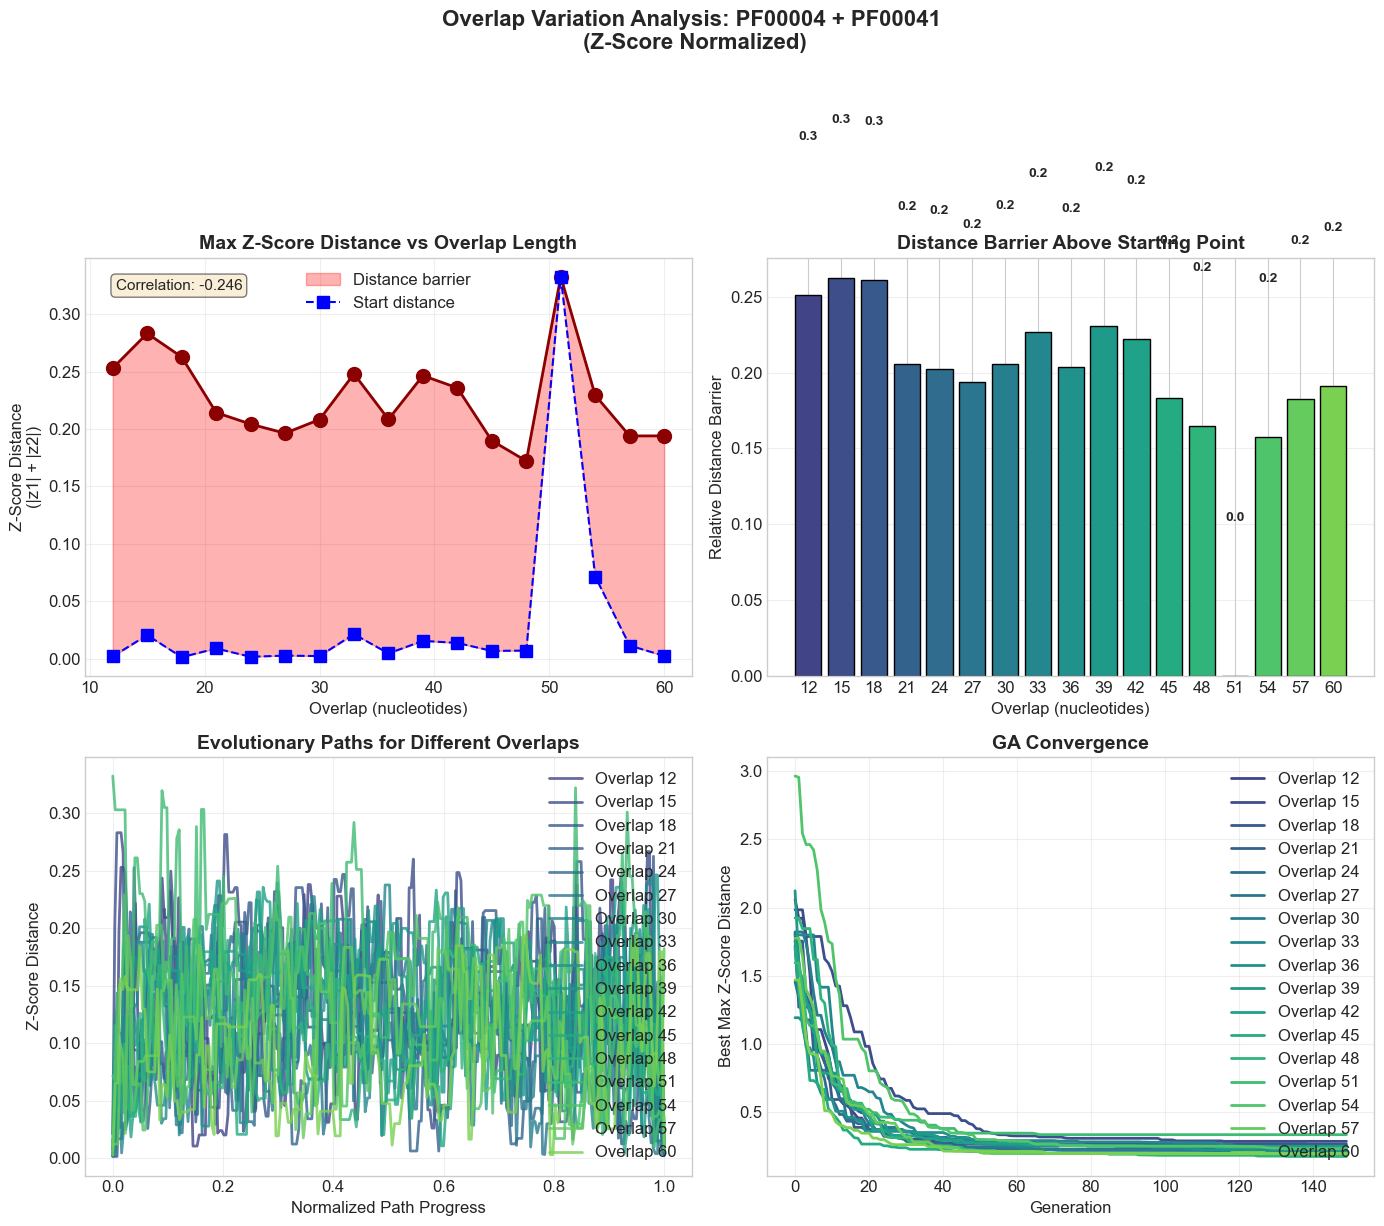

In [9]:
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results)))
    
    # Dynamic ylabel based on Z_SCORE setting
    dist_ylabel = "Z-Score Distance\n(|z1| + |z2|)" if Z_SCORE else "Distance from Natural\n(|E1-mean1| + |E2-mean2|)"
    
    # Plot 1: Max Distance from Natural vs Overlap
    ax1 = axes[0, 0]
    ax1.plot(overlaps, max_distances, 'o-', color='darkred', linewidth=2, markersize=10)
    ax1.fill_between(overlaps, start_distances, max_distances, alpha=0.3, color='red', label='Distance barrier')
    ax1.plot(overlaps, start_distances, 's--', color='blue', linewidth=1.5, markersize=8, label='Start distance')
    ax1.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax1.set_ylabel(dist_ylabel, fontsize=12)
    ax1.set_title(f'{MAX_DIST_LABEL} vs Overlap Length', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add correlation
    if len(overlaps) > 2:
        corr = np.corrcoef(overlaps, max_distances)[0, 1]
        ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax1.transAxes, 
                 fontsize=11, verticalalignment='top', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Plot 2: Relative Distance (above starting point)
    ax2 = axes[0, 1]
    bars = ax2.bar(range(len(overlaps)), relative_distances, color=colors, edgecolor='black')
    ax2.set_xticks(range(len(overlaps)))
    ax2.set_xticklabels([str(o) for o in overlaps])
    ax2.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax2.set_ylabel('Relative Distance Barrier', fontsize=12)
    ax2.set_title('Distance Barrier Above Starting Point', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, val in zip(bars, relative_distances):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 3: Distance Paths for all overlaps
    ax3 = axes[1, 0]
    for i, r in enumerate(results):
        path = r['path_distances']
        x = np.linspace(0, 1, len(path))
        ax3.plot(x, path, '-', color=colors[i], linewidth=2, alpha=0.8,
                 label=f"Overlap {r['overlap']}")
    
    ax3.set_xlabel('Normalized Path Progress', fontsize=12)
    ax3.set_ylabel(DIST_LABEL, fontsize=12)
    ax3.set_title('Evolutionary Paths for Different Overlaps', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: GA Convergence
    ax4 = axes[1, 1]
    for i, r in enumerate(results):
        ax4.plot(r['fitness_history'], color=colors[i], linewidth=2, 
                 label=f"Overlap {r['overlap']}")
    
    ax4.set_xlabel('Generation', fontsize=12)
    ax4.set_ylabel(f'Best Max {DIST_LABEL}', fontsize=12)
    ax4.set_title('GA Convergence', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    z_score_text = " (Z-Score Normalized)" if Z_SCORE else " (Raw Energy Units)"
    plt.suptitle(f'Overlap Variation Analysis: {PROTEIN_1} + {PROTEIN_2}\n{z_score_text}', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('overlap_variation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

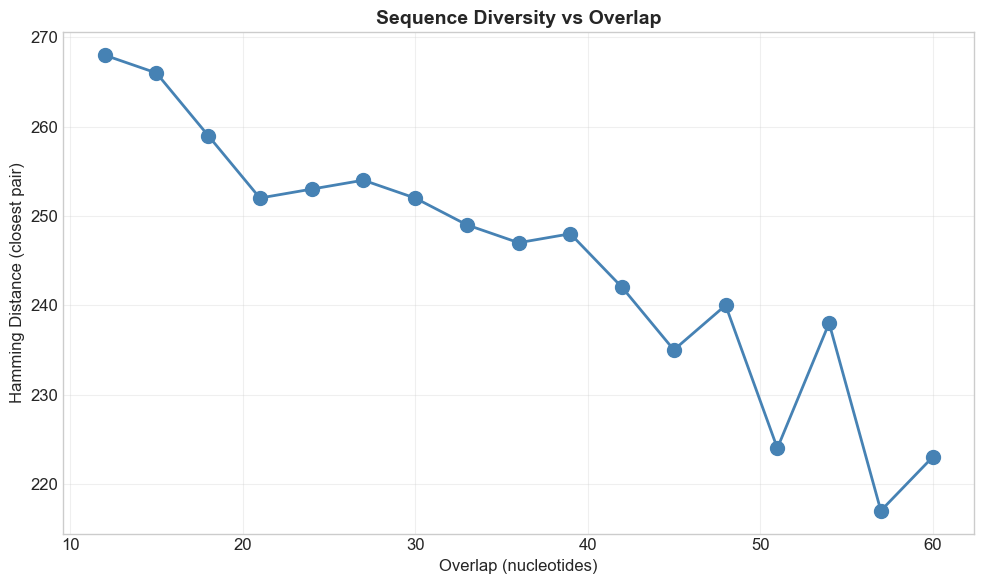

In [10]:
if len(results) > 0:
    # Additional plot: Hamming distance vs Overlap
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(overlaps, ham_dists, 'o-', color='steelblue', linewidth=2, markersize=10)
    ax.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax.set_ylabel('Hamming Distance (closest pair)', fontsize=12)
    ax.set_title('Sequence Diversity vs Overlap', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('hamming_vs_overlap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Save Results

In [11]:
if len(results) > 0:
    # Create summary DataFrame with distance metrics
    df = pd.DataFrame([{
        'overlap': r['overlap'],
        'hamming_distance': r['hamming_distance'],
        'n_mutations': r['n_mutations'],
        'max_distance_from_natural': r['max_distance_from_natural'],
        'start_distance': r['start_distance'],
        'end_distance': r['end_distance'],
        'relative_distance': r['max_distance_from_natural'] - r['start_distance'],
        'start_energy': r['start_energy'],
        'end_energy': r['end_energy'],
        'mean_e1': r['mean_e1'],
        'mean_e2': r['mean_e2'],
        'nat_mean_1': mean_e1,
        'nat_mean_2': mean_e2,
        'protein_1': PROTEIN_1,
        'protein_2': PROTEIN_2
    } for r in results])
    
    df.to_csv('overlap_variation_results.csv', index=False)
    print("Results saved to overlap_variation_results.csv")
    display(df)

Results saved to overlap_variation_results.csv


,overlap,hamming_distance,n_mutations,max_distance_from_natural,start_distance,end_distance,relative_distance,start_energy,end_energy,mean_e1,mean_e2,nat_mean_1,nat_mean_2,protein_1,protein_2
0,12,268,268,0.253024,0.002065,0.004478,0.250960,266.462167,266.379118,145.872204,120.644780,145.879371,120.656011,PF00004,PF00041
1,15,266,266,0.283165,0.020644,0.007537,0.262521,266.625316,266.779522,146.618479,120.674770,145.879371,120.656011,PF00004,PF00041
2,18,259,259,0.262646,0.001409,0.015043,0.261237,266.532510,266.123819,145.837774,120.718680,145.879371,120.656011,PF00004,PF00041
3,21,252,252,0.214315,0.008977,0.006376,0.205338,266.275164,266.660644,145.934670,120.654887,145.879371,120.656011,PF00004,PF00041
4,24,253,253,0.204235,0.001766,0.003077,0.202469,266.573221,266.598650,145.900116,120.628590,145.879371,120.656011,PF00004,PF00041
5,27,254,254,0.196289,0.002765,0.003406,0.193524,266.633837,266.620434,145.820614,120.669352,145.879371,120.656011,PF00004,PF00041
6,30,252,252,0.208227,0.002361,0.002013,0.205866,266.543769,266.496968,145.900244,120.644077,145.879371,120.656011,PF00004,PF00041
7,33,249,249,0.247987,0.021460,0.023038,0.226526,266.078129,266.894662,145.843094,120.687636,145.879371,120.656011,PF00004,PF00041
8,36,247,247,0.208436,0.004648,0.009936,0.203789,266.617415,266.386857,145.929045,120.670710,145.879371,120.656011,PF00004,PF00041
9,39,248,248,0.246459,0.015612,0.032191,0.230847,266.435753,267.475440,146.279165,120.963712,145.879371,120.656011,PF00004,PF00041


## 9. Statistical Analysis

In [12]:
if len(results) >= 3:
    from scipy import stats
    
    # Linear regression: max distance from natural vs overlap
    slope, intercept, r_value, p_value, std_err = stats.linregress(overlaps, max_distances)
    
    print("Linear Regression: Max Distance from Natural vs Overlap")
    print("=" * 55)
    print(f"  Slope: {slope:.4f} (distance per nucleotide of overlap)")
    print(f"  Intercept: {intercept:.2f}")
    print(f"  R-squared: {r_value**2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print()
    
    if p_value < 0.05 and slope > 0:
        print("Conclusion: SIGNIFICANT positive relationship between overlap and distance from natural.")
        print("This supports the hypothesis that evolvability decreases with increasing overlap.")
    elif slope > 0:
        print("Conclusion: Positive trend observed but not statistically significant.")
        print("More data points may be needed to confirm the relationship.")
    else:
        print("Conclusion: No clear positive relationship observed.")

Linear Regression: Max Distance from Natural vs Overlap
  Slope: -0.0007 (distance per nucleotide of overlap)
  Intercept: 0.25
  R-squared: 0.0603
  P-value: 0.3420

Conclusion: No clear positive relationship observed.


## 10. Summary

### Hypothesis
Evolvability (ability to find evolutionary paths with low energy barriers) decreases as gene overlap increases.

### Method
- Generated functional overlapping sequences at multiple overlap lengths
- Found closest sequence pairs (minimum Hamming distance) at each overlap
- Used Genetic Algorithm to find optimal mutation ordering
- Measured maximum energy barrier along the evolutionary path

### Expected Result
If the hypothesis is correct, we should see:
1. Energy barriers increase with overlap
2. Positive correlation between overlap and barrier height

### Interpretation
Higher energy barriers mean:
- More difficult evolutionary transitions
- Stronger purifying selection required
- Reduced evolvability in overlapping regions